In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt

In [2]:
df_pp = pd.read_csv('palmer_penguins.csv')
print(df_pp.dtypes)

species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm      int64
body_mass_g            int64
sex                   object
year                   int64
dtype: object


In [3]:
df_pp

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181,3750,male,2007
1,Adelie,Torgersen,39.5,17.4,186,3800,female,2007
2,Adelie,Torgersen,40.3,18.0,195,3250,female,2007
3,Adelie,Torgersen,36.7,19.3,193,3450,female,2007
4,Adelie,Torgersen,39.3,20.6,190,3650,male,2007
...,...,...,...,...,...,...,...,...
328,Chinstrap,Dream,55.8,19.8,207,4000,male,2009
329,Chinstrap,Dream,43.5,18.1,202,3400,female,2009
330,Chinstrap,Dream,49.6,18.2,193,3775,male,2009
331,Chinstrap,Dream,50.8,19.0,210,4100,male,2009


In [4]:
df_pp.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,333.000000,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057,2008.042042
std,5.468668,1.969235,14.015765,805.215802,0.812944
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.500000,15.600000,190.000000,3550.000000,2007.000000
50%,44.500000,17.300000,197.000000,4050.000000,2008.000000
75%,48.600000,18.700000,213.000000,4775.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


In [5]:
# Count of missing values (NaNs) in each column of df_pp
missing_counts = df_pp.isna().sum()
print(missing_counts)

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
year                 0
dtype: int64


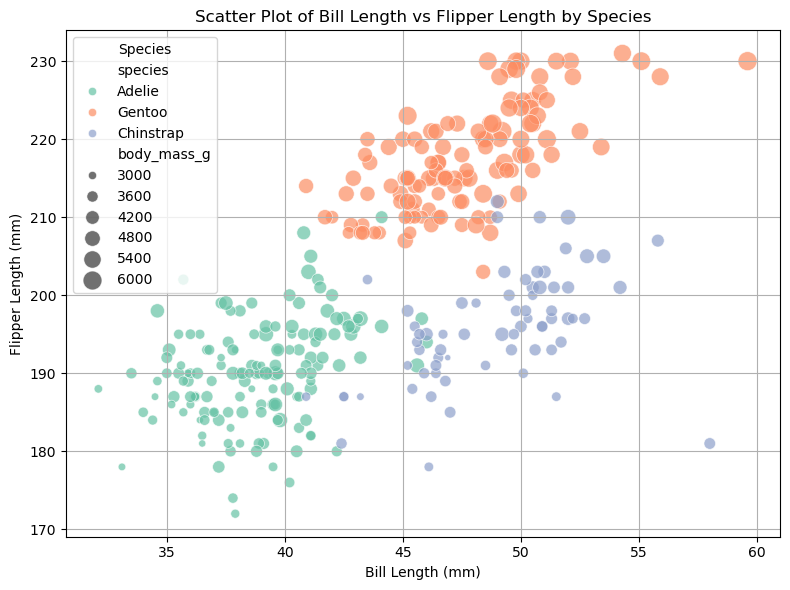

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Drop rows with missing values in the relevant columns
df_clean = df_pp.dropna(subset=['bill_length_mm', 'flipper_length_mm', 'species'])

# Create scatter plot of bill length vs flipper length colored by species
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_clean,
    x='bill_length_mm',
    y='flipper_length_mm',
    hue='species',
    size='body_mass_g',  # size by body mass to hint at density/variation
    sizes=(20, 200),
    alpha=0.7,
    palette='Set2'
)
plt.title("Scatter Plot of Bill Length vs Flipper Length by Species")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Flipper Length (mm)")
plt.legend(title="Species")
plt.grid(True)
plt.tight_layout()
plt.show()


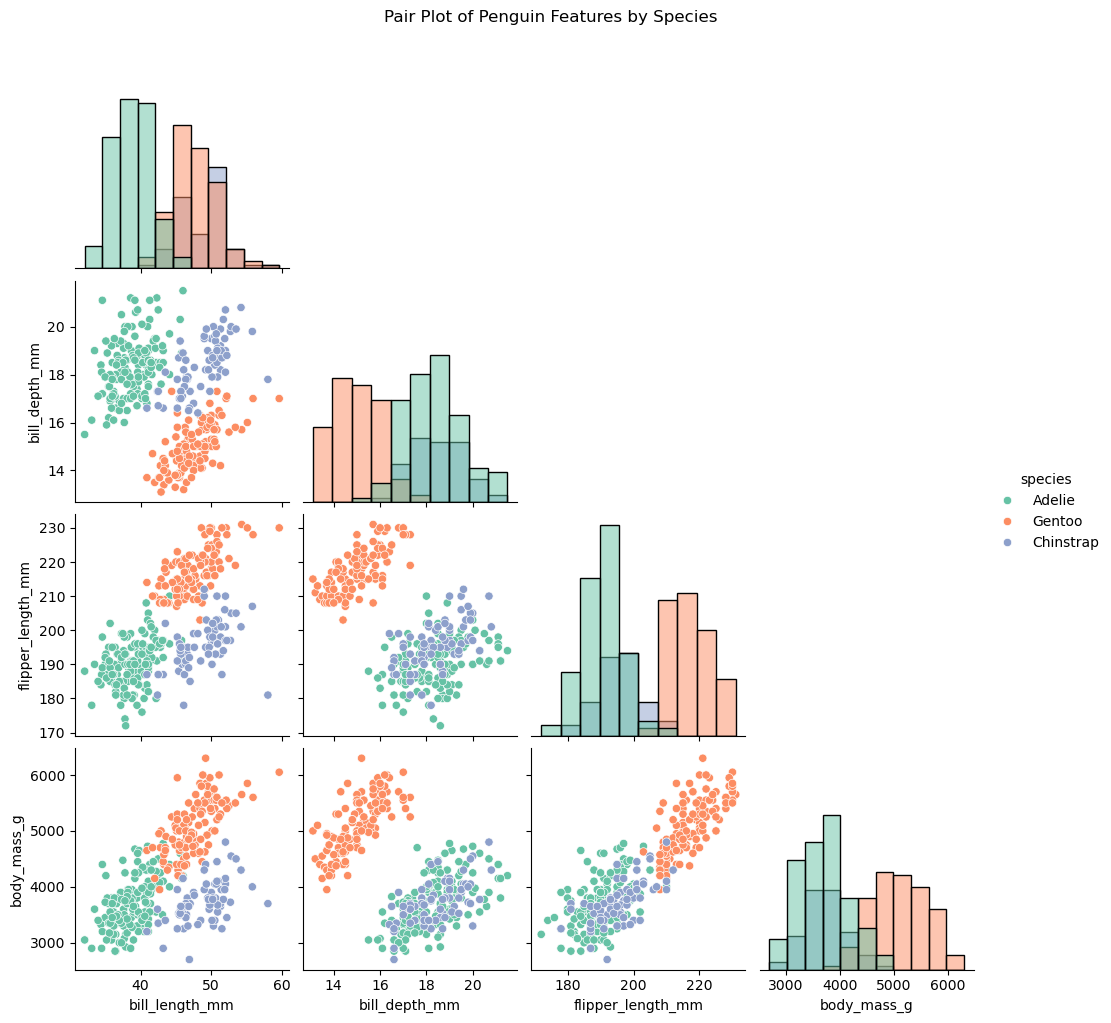

In [7]:
# Use histplot on the diagonal instead of KDE to avoid rendering issues with fill_between
# Step 1: Select relevant columns
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'species']

# Step 2: Drop rows with missing values in any of the selected columns
df_pairplot_clean = df_pp[features].dropna()

sns.pairplot(df_pairplot_clean, hue='species', corner=True, palette='Set2', diag_kind='hist')
plt.suptitle("Pair Plot of Penguin Features by Species", y=1.02)
plt.show()


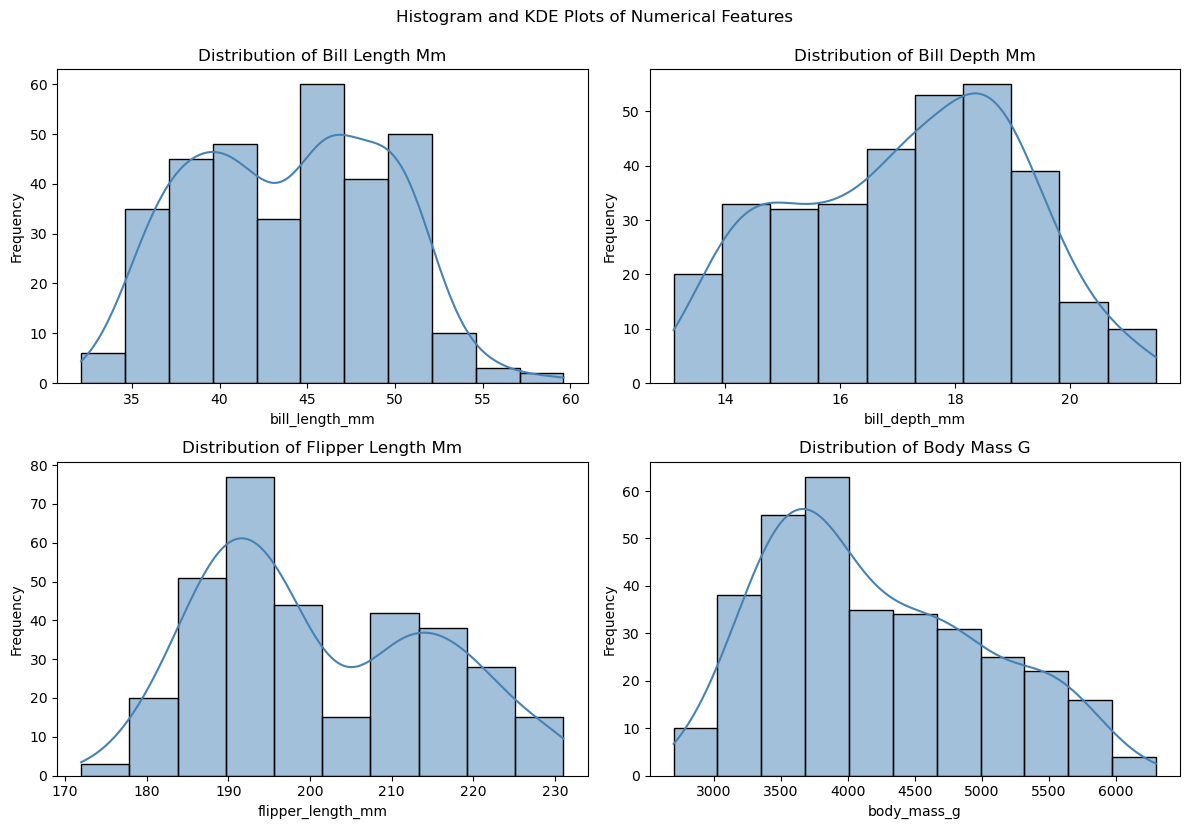

In [8]:
# Select numerical features relevant for clustering
numeric_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
df_hk_clean = df_pp[numeric_features].dropna()

# Create histogram/KDE plots to check feature distributions
plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df_hk_clean[col], kde=True, color='steelblue')
    plt.title(f"Distribution of {col.replace('_', ' ').title()}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.suptitle("Histogram and KDE Plots of Numerical Features", y=1.03)
plt.show()

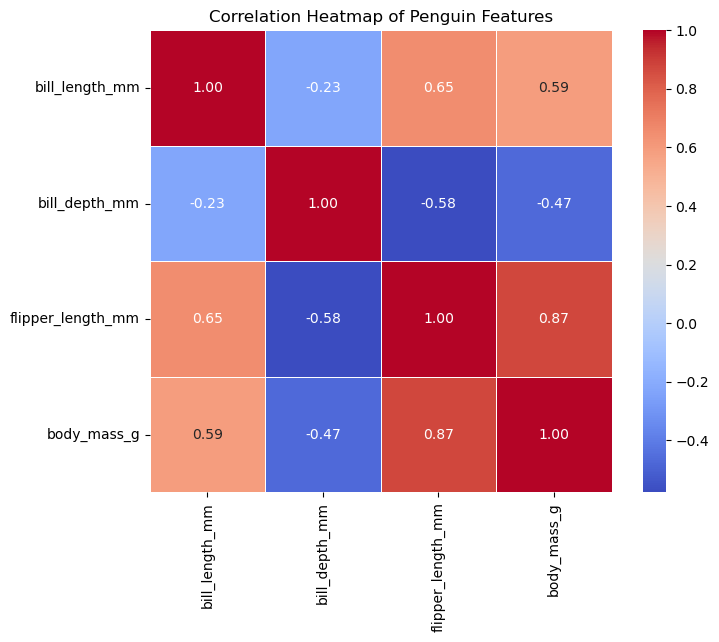

In [9]:
corr_matrix = df_hk_clean .corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, square=True)
plt.title("Correlation Heatmap of Penguin Features")
plt.show()


In [10]:
def initialize_centroids(X, k, seed=42):
    np.random.seed(seed)
    random_indices = np.random.choice(X.shape[0], k, replace=False)
    return X[random_indices]

def assign_clusters(X, centroids):
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)  # shape: (n_samples, k)
    return np.argmin(distances, axis=1)

def update_centroids(X, labels, k):
    return np.array([X[labels == i].mean(axis=0) for i in range(k)])

def compute_wcss(X, labels, centroids):
    return sum(np.sum((X[labels == i] - centroids[i]) ** 2) for i in range(len(centroids)))

def kmeans_with_tracking(X, k, max_iters=100, seed=42, plot_steps=True):
    centroids = initialize_centroids(X, k, seed)
    history = {'centroids': [centroids.copy()], 'labels': []}
    
    for _ in range(max_iters):
        labels = assign_clusters(X, centroids)
        history['labels'].append(labels.copy())

        new_centroids = update_centroids(X, labels, k)
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids
        history['centroids'].append(centroids.copy())

    final_wcss = compute_wcss(X, labels, centroids)

    if plot_steps:
        n_steps = len(history['labels'])
        n_cols = 5
        n_rows = int(np.ceil(n_steps / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
        axes = axes.flatten()
        for i in range(n_steps):
            axes[i].scatter(X[:, 0], X[:, 1], c=history['labels'][i], cmap='viridis', s=30)
            axes[i].scatter(history['centroids'][i][:, 0], history['centroids'][i][:, 1], 
                            c='red', s=100, marker='X')
            axes[i].set_title(f"Iteration {i + 1}")
        for j in range(n_steps, n_rows * n_cols):
            axes[j].axis('off')
        plt.tight_layout()
        plt.show()

    return centroids, labels, final_wcss

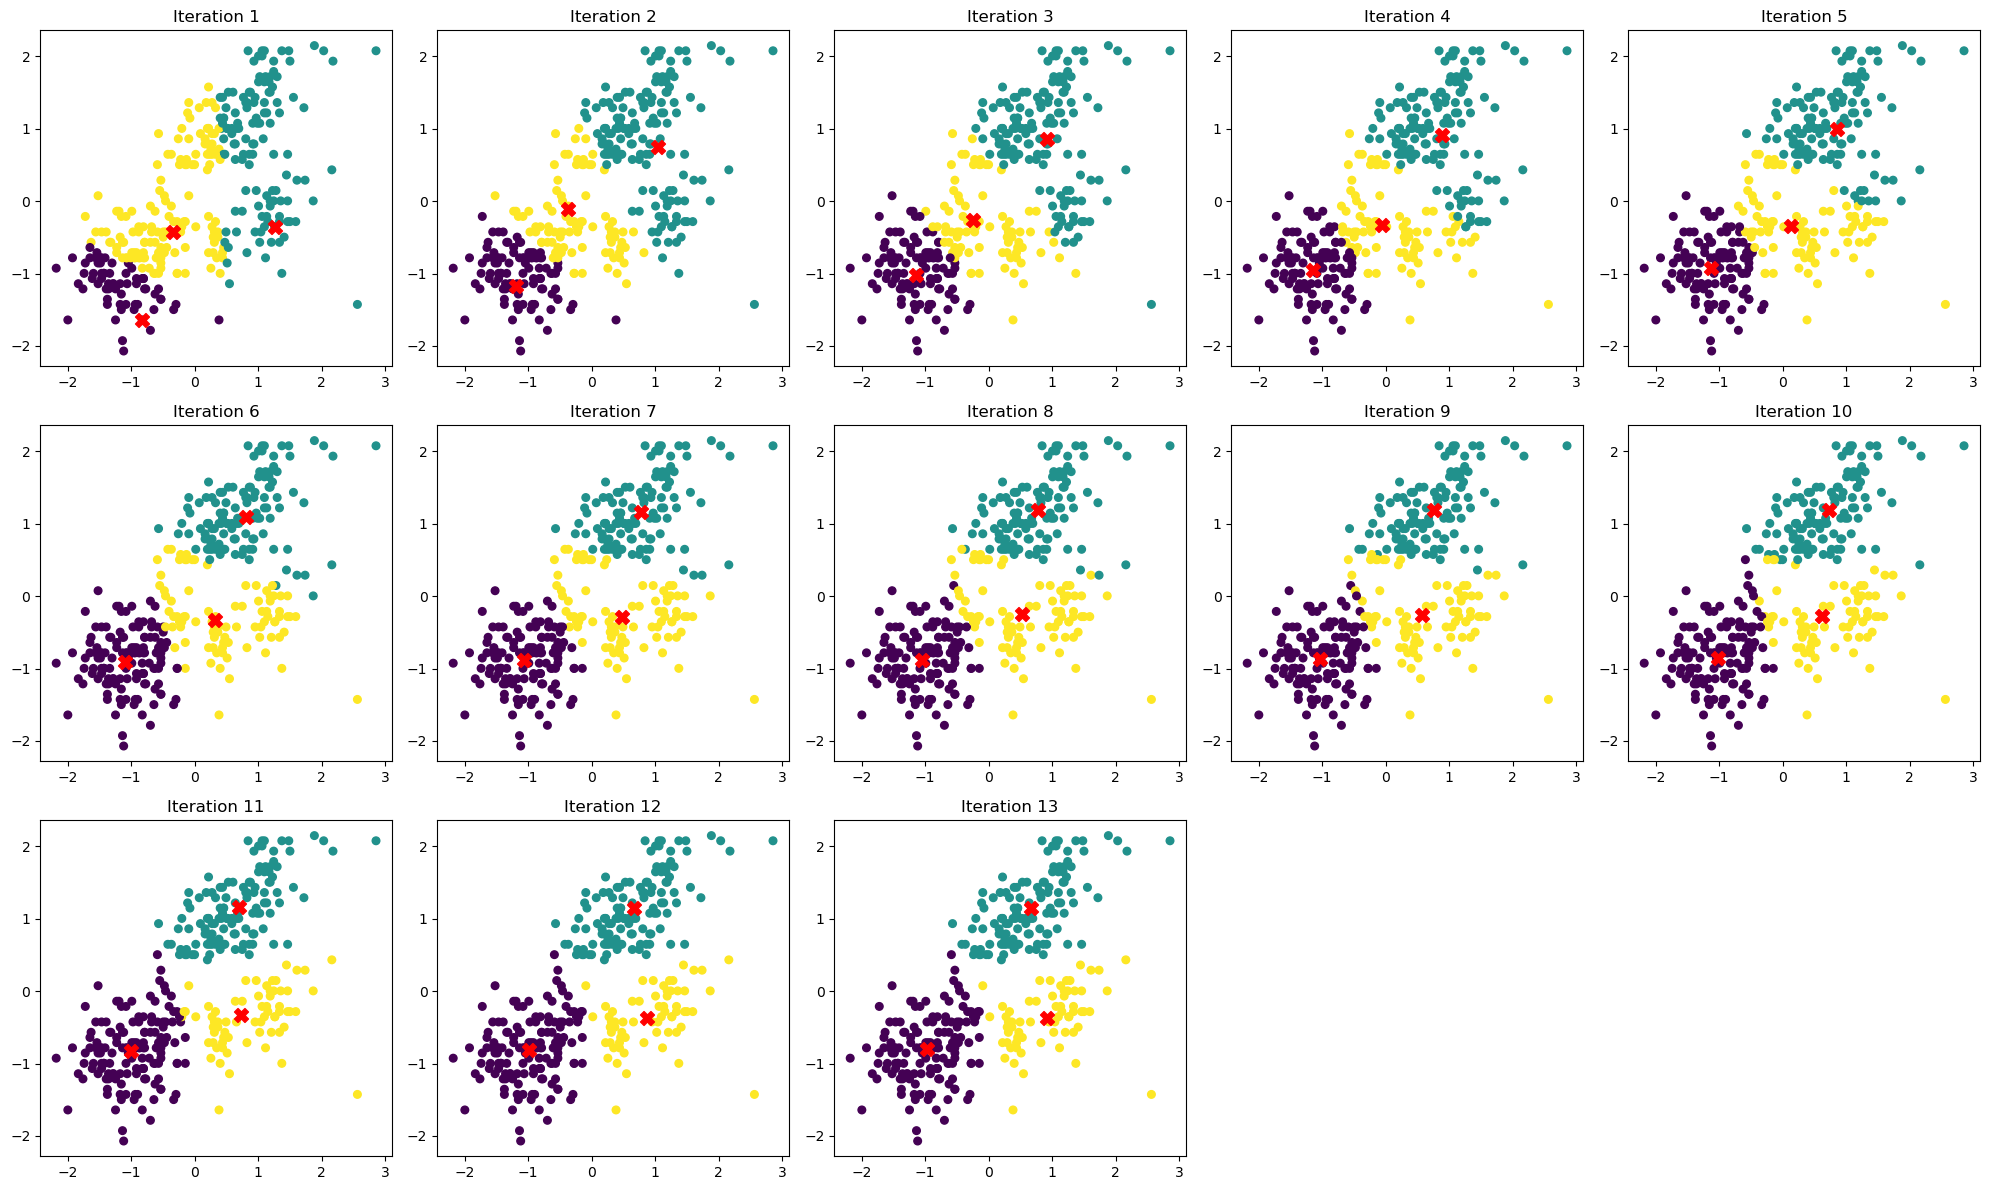

In [11]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import adjusted_rand_score


# 1. Prepare the data
df_pp_scale = df_pp[['bill_length_mm', 'flipper_length_mm']].dropna()

# 2. Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pp_scale)

# 3. Encode ground truth species labels
le = LabelEncoder()
true_labels = le.fit_transform(df_pp['species'])

# 4. Apply the algorithm to the standardized data
centroids_custom, labels_custom, wcss_custom = kmeans_with_tracking(X_scaled, k=3)
ari_custom = adjusted_rand_score(true_labels, labels_custom)


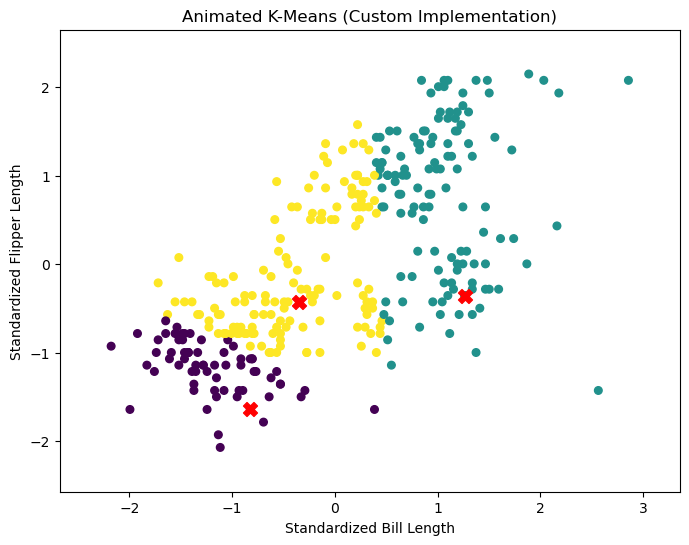

In [12]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np

# Assume you already ran this:
# centroids_custom, labels_custom, wcss_custom = kmeans_with_tracking(X_scaled, k=3, plot_steps=False)

# Regenerate history from your tracking function
def get_kmeans_history(X, k, max_iters=20, seed=42):
    centroids = initialize_centroids(X, k, seed)
    history = {'centroids': [centroids.copy()], 'labels': []}
    for _ in range(max_iters):
        labels = assign_clusters(X, centroids)
        history['labels'].append(labels.copy())
        new_centroids = update_centroids(X, labels, k)
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids
        history['centroids'].append(centroids.copy())
    return history

history = get_kmeans_history(X_scaled, k=3)

# === Animate ===
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=history['labels'][0], cmap='viridis', s=30)
centroid_sc = ax.scatter(history['centroids'][0][:, 0], history['centroids'][0][:, 1], 
                         c='red', s=100, marker='X')

ax.set_xlim(X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5)
ax.set_ylim(X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5)
ax.set_title("Animated K-Means (Custom Implementation)")
ax.set_xlabel("Standardized Bill Length")
ax.set_ylabel("Standardized Flipper Length")

def update(frame):
    sc.set_array(np.array(history['labels'][frame]))
    centroid_sc.set_offsets(history['centroids'][frame])
    return sc, centroid_sc

ani = FuncAnimation(fig, update, frames=len(history['labels']), interval=800, repeat=False)
plt.show()


In [19]:
ani.save("kmeans_animation.gif", writer="pillow")


In [13]:
print(f"Centroids (Custom K-Means):\n{centroids_custom}")
print(f"Custom K-Means WCSS: {wcss_custom:.2f}")
print(f"Custom K-Means Adjusted Rand Index: {ari_custom:.4f}")

Centroids (Custom K-Means):
[[-0.96427851 -0.80518575]
 [ 0.66403058  1.15087842]
 [ 0.9235766  -0.37501448]]
Custom K-Means WCSS: 154.85
Custom K-Means Adjusted Rand Index: 0.8834


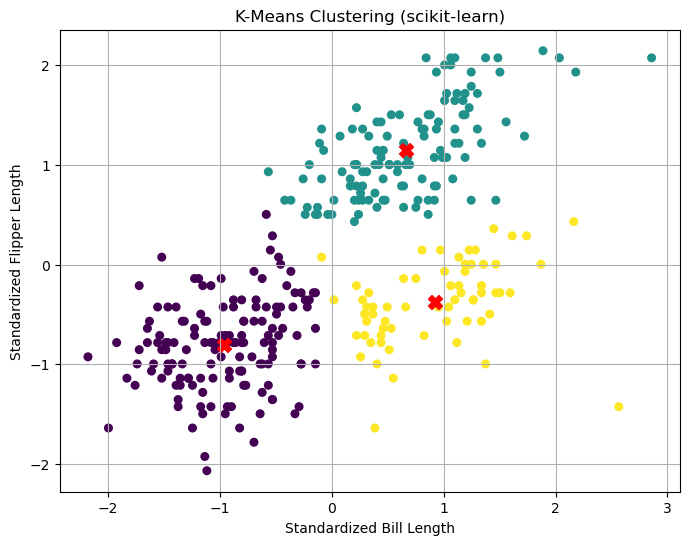

In [14]:
from sklearn.cluster import KMeans

X = df_pp_scale .values
scaler = StandardScaler()
X_scaled1 = scaler.fit_transform(X)

# Step 3: Encode species labels numerically for comparison
le = LabelEncoder()
true_labels = le.fit_transform(df_clean['species'])

# Step 4: Apply scikit-learn's built-in KMeans
kmeans_builtin = KMeans(n_clusters=3, random_state=42, n_init=10)
builtin_labels = kmeans_builtin.fit_predict(X_scaled1)

# Step 5: Evaluate with Adjusted Rand Index (ARI)
ari_score = adjusted_rand_score(true_labels, builtin_labels)

# Output: Centroids and WCSS for built-in KMeans
centroids_builtin = kmeans_builtin.cluster_centers_
wcss_builtin = kmeans_builtin.inertia_


plt.figure(figsize=(8, 6))
plt.scatter(X_scaled1[:, 0], X_scaled1[:, 1], c=builtin_labels, cmap='viridis', s=30)
plt.scatter(centroids_builtin[:, 0], centroids_builtin[:, 1], c='red', s=100, marker='X')
plt.title("K-Means Clustering (scikit-learn)")
plt.xlabel("Standardized Bill Length")
plt.ylabel("Standardized Flipper Length")
plt.grid(True)
plt.show()


In [15]:

print(f"Centroids (Scikit-learn KMeans):\n{centroids_builtin}")
print(f"Scikit-learn KMeans Adjusted Rand Index: {ari_score:.4f}")
print(f"Scikit-learn KMeans WCSS: {wcss_builtin:.2f}")

Centroids (Scikit-learn KMeans):
[[-0.96427851 -0.80518575]
 [ 0.66403058  1.15087842]
 [ 0.9235766  -0.37501448]]
Scikit-learn KMeans Adjusted Rand Index: 0.8834
Scikit-learn KMeans WCSS: 154.85


In [16]:
# Comparison table between custom and scikit-learn KMeans

comparison_df = pd.DataFrame({
    'Metric': ['WCSS', 'Adjusted Rand Index'],
    'Custom K-Means': [
        f"{wcss_custom:.2f}",
        f"{ari_custom:.4f}"
    ],
    'Scikit-learn KMeans': [
        f"{wcss_builtin:.2f}",
        f"{ari_score:.4f}"
    ]
})

comparison_df

,Metric,Custom K-Means,Scikit-learn KMeans
0,WCSS,154.85,154.85
1,Adjusted Rand Index,0.8834,0.8834


WCSS for different K values: [243.1727902430793, 154.84546009071224, 116.22992785055912, 89.8787514461375, 77.15139118747717, 65.76329426688733]
Silhouette Scores for different K values: [0.5388755534650435, 0.518869393287823, 0.5040149452257723, 0.43335050630380545, 0.4007298336057708, 0.41010401090116616]


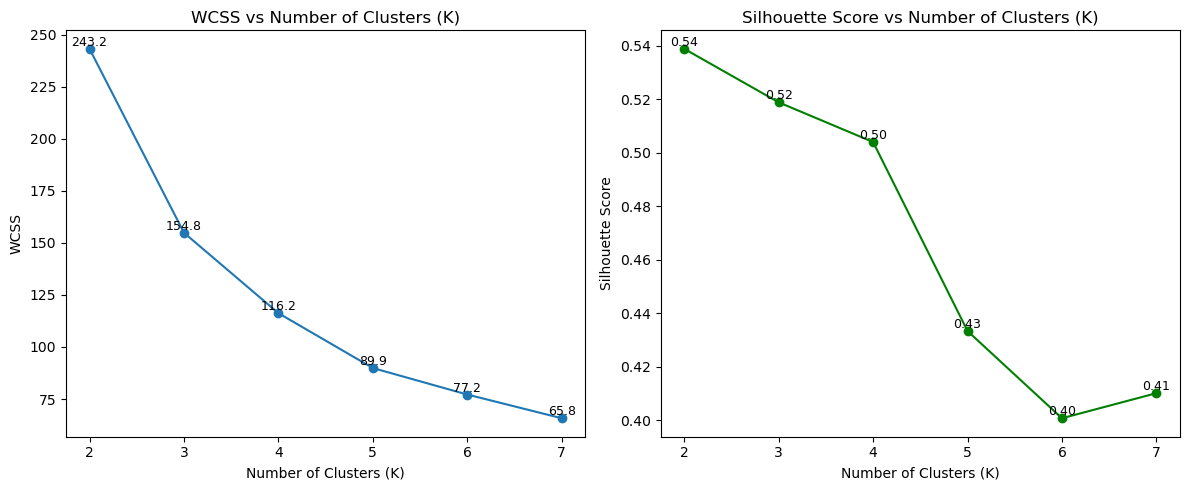

In [17]:
from sklearn.metrics import silhouette_score
# Function to calculate WCSS and silhouette score for a range of K values
def evaluate_kmeans(X, k_range):
    wcss = []
    silhouette_scores = []
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        
        # Calculate WCSS
        wcss.append(kmeans.inertia_)
        
        # Calculate silhouette score
        if k > 1:  # Silhouette score is undefined for k=1
            silhouette_scores.append(silhouette_score(X, labels))
        else:
            silhouette_scores.append(None)
    
    return wcss, silhouette_scores
k_range = range(2, 8)  # Testing K from 2 to 7
wcss, silhouette_scores = evaluate_kmeans(X_scaled1, k_range)


print("WCSS for different K values:", wcss)
print("Silhouette Scores for different K values:", silhouette_scores)

# Plot results
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot WCSS
ax[0].plot(k_range, wcss, marker='o')
ax[0].set_title('WCSS vs Number of Clusters (K)')
ax[0].set_xlabel('Number of Clusters (K)')
ax[0].set_ylabel('WCSS')
ax[0].set_xticks(list(k_range))
for x, y in zip(k_range, wcss):
    ax[0].text(x, y, f"{y:.1f}", ha='center', va='bottom', fontsize=9)

# Plot Silhouette Scores
ax[1].plot(k_range, silhouette_scores, marker='o', color='green')
ax[1].set_title('Silhouette Score vs Number of Clusters (K)')
ax[1].set_xlabel('Number of Clusters (K)')
ax[1].set_ylabel('Silhouette Score')
ax[1].set_xticks(list(k_range))
for x, y in zip(k_range, silhouette_scores):
    ax[1].text(x, y, f"{y:.2f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


In [18]:
# Identify the optimal number of clusters using the "elbow" in WCSS and the maximum silhouette score

# Find the "elbow" point in WCSS (where the decrease in WCSS slows down)
# A simple approach: look for the point where the relative decrease drops below a threshold
wcss_diff = np.diff(wcss)
wcss_diff_ratio = np.abs(wcss_diff / wcss[:-1])
elbow_threshold = 0.5  # You can adjust this threshold
elbow_candidates = np.where(wcss_diff_ratio < elbow_threshold)[0]
if len(elbow_candidates) > 0:
    optimal_k_elbow = k_range[elbow_candidates[0] + 1]
else:
    optimal_k_elbow = k_range[0]

# Find the number of clusters with the highest silhouette score
silhouette_scores_valid = [s for s in silhouette_scores if s is not None]
optimal_k_silhouette = k_range[np.argmax(silhouette_scores_valid) + 1]  # +1 because k_range starts at 2

print(f"Optimal K by Elbow Method (WCSS): {optimal_k_elbow}")
print(f"Optimal K by Maximum Silhouette Score: {optimal_k_silhouette}")

Optimal K by Elbow Method (WCSS): 3
Optimal K by Maximum Silhouette Score: 3


In [21]:
import numpy as np
import pandas as pd

# Set seed for reproducibility
np.random.seed(42)

# Generate random data
n = 100
x1 = np.random.uniform(-3, 3, n)
x2 = np.random.uniform(-3, 3, n)

# Define a wiggly nonlinear boundary
boundary = np.sin(4 * x1) + x1

# Assign labels based on position relative to the boundary
y = (x2 > boundary).astype(int)  # 1 if above boundary, 0 otherwise

# Create DataFrame
dat = pd.DataFrame({
    'x1': x1,
    'x2': x2,
    'y': y
})
dat['y'] = dat['y'].astype('category')

# Preview the dataset
print(dat.head())

         x1        x2  y
0 -0.752759 -2.811425  0
1  2.704286  0.818462  0
2  1.391964 -1.113864  0
3  0.591951  0.051424  0
4 -2.063888  2.445399  1


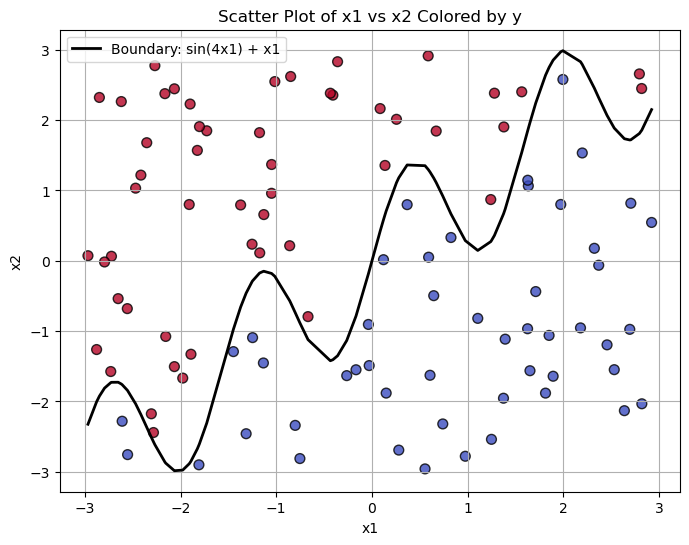

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(dat['x1'], dat['x2'], c=dat['y'].cat.codes, cmap='coolwarm', s=50, edgecolor='k', alpha=0.8)
# Draw the wiggly boundary
x1_sorted = np.sort(dat['x1'])
boundary_sorted = np.sin(4 * x1_sorted) + x1_sorted
plt.plot(x1_sorted, boundary_sorted, color='black', linewidth=2, label='Boundary: sin(4x1) + x1')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Scatter Plot of x1 vs x2 Colored by y')
plt.grid(True)
plt.legend()
plt.show()

         x1        x2  y
0 -2.542150 -2.584488  0
1  1.679513 -0.857576  0
2 -0.369545  1.876977  1
3  1.340791 -0.433771  0
4  2.867937  0.599127  0


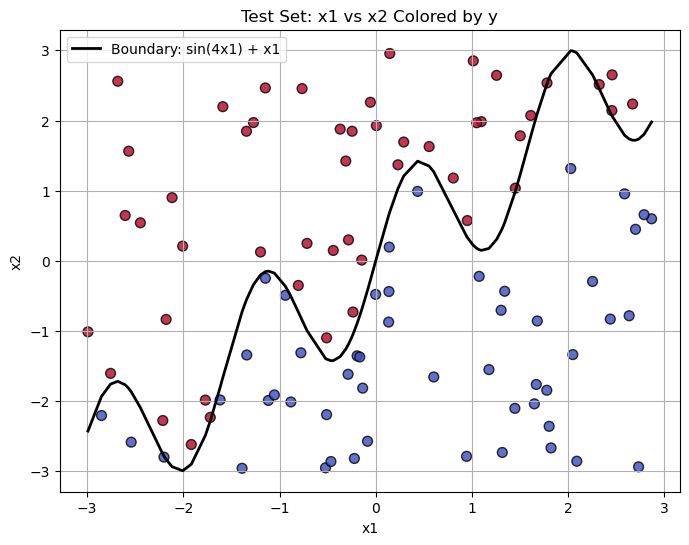

In [24]:

# Generate test dataset using a different seed
np.random.seed(7)
n = 100
x1_test = np.random.uniform(-3, 3, n)
x2_test = np.random.uniform(-3, 3, n)
boundary_test = np.sin(4 * x1_test) + x1_test
y_test = (x2_test > boundary_test).astype(int)

# Create DataFrame
test_dat = pd.DataFrame({
    'x1': x1_test,
    'x2': x2_test,
    'y': pd.Categorical(y_test)
})

print(test_dat.head())

# Plot the test dataset with boundary
plt.figure(figsize=(8, 6))
plt.scatter(test_dat['x1'], test_dat['x2'], c=test_dat['y'].cat.codes, cmap='coolwarm', s=50, edgecolor='k', alpha=0.8)

# Plot the boundary line
x1_sorted = np.sort(test_dat['x1'])
boundary_sorted = np.sin(4 * x1_sorted) + x1_sorted
plt.plot(x1_sorted, boundary_sorted, color='black', linewidth=2, label='Boundary: sin(4x1) + x1')

# Labels and title
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Test Set: x1 vs x2 Colored by y')
plt.grid(True)
plt.legend()
plt.show()


In [25]:

from collections import Counter

def euclidean_distance(a, b):
    """Compute Euclidean distance between two points a and b"""
    return np.sqrt(np.sum((a - b)**2))

def knn_predict(X_train, y_train, X_test, k=3):
    """
    Predict labels for X_test using KNN based on X_train and y_train.
    
    Parameters:
    - X_train: array of shape (n_train, n_features)
    - y_train: array of shape (n_train,)
    - X_test: array of shape (n_test, n_features)
    - k: number of neighbors to use

    Returns:
    - predictions: array of shape (n_test,)
    """
    predictions = []

    for test_point in X_test:
        # Compute distances from test_point to all training points
        distances = [euclidean_distance(test_point, train_point) for train_point in X_train]
        
        # Get indices of the k closest points
        k_indices = np.argsort(distances)[:k]
        
        # Retrieve the corresponding labels
        k_labels = [y_train[i] for i in k_indices]
        
        # Use majority vote to determine prediction
        most_common = Counter(k_labels).most_common(1)[0][0]
        predictions.append(most_common)

    return np.array(predictions)

# Assume you already have dat (train set) and test_dat (test set)
X_train = dat[['x1', 'x2']].values
y_train = dat['y'].astype(int).values
X_test = test_dat[['x1', 'x2']].values
y_test = test_dat['y'].astype(int).values

# Predict using k = 5
y_pred = knn_predict(X_train, y_train, X_test, k=5)

# Evaluate accuracy
accuracy = np.mean(y_pred == y_test)
print(f"KNN (handwritten) accuracy with k=5: {accuracy:.2%}")



KNN (handwritten) accuracy with k=5: 88.00%


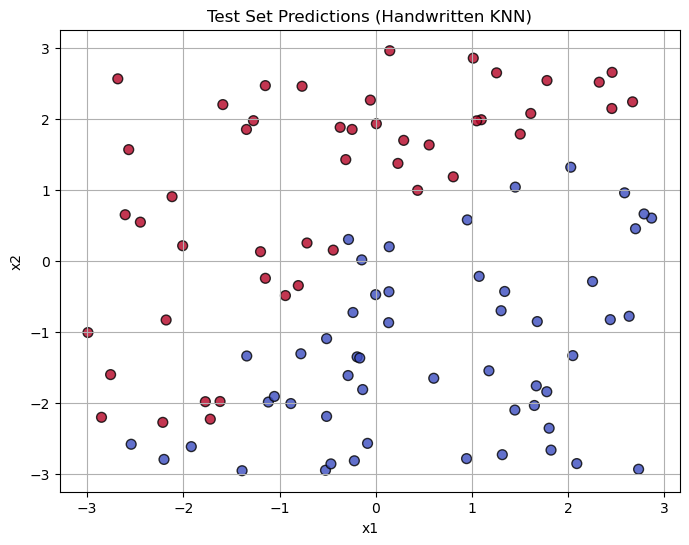

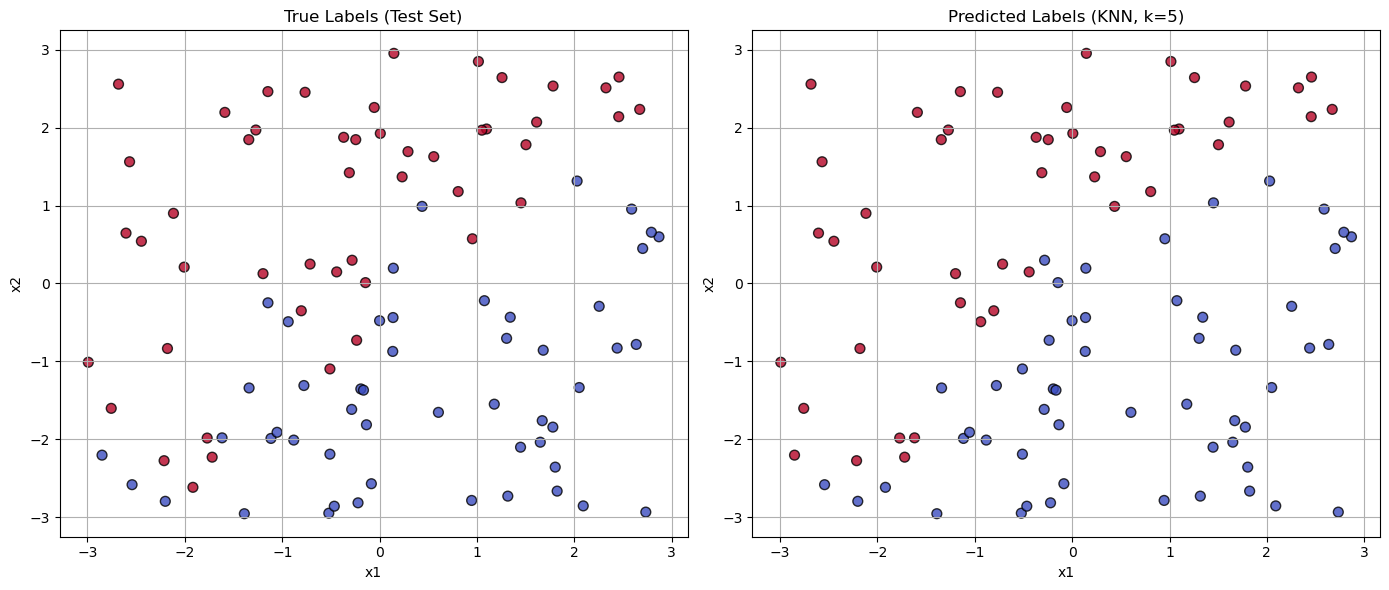

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap='coolwarm', s=50, edgecolor='k', alpha=0.8)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Test Set Predictions (Handwritten KNN)')
plt.grid(True)
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# True labels
ax[0].scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='coolwarm', s=50, edgecolor='k', alpha=0.8)
ax[0].set_title("True Labels (Test Set)")
ax[0].set_xlabel("x1")
ax[0].set_ylabel("x2")
ax[0].grid(True)

# Predicted labels
ax[1].scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap='coolwarm', s=50, edgecolor='k', alpha=0.8)
ax[1].set_title("Predicted Labels (KNN, k=5)")
ax[1].set_xlabel("x1")
ax[1].set_ylabel("x2")
ax[1].grid(True)

plt.tight_layout()
plt.show()



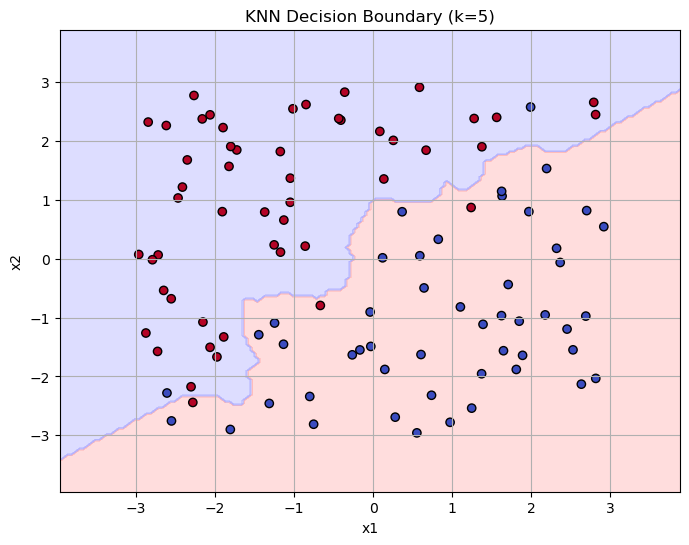

In [28]:
# Requires: X_train, y_train, knn model (fitted or custom)

from matplotlib.colors import ListedColormap

# Create a meshgrid of points
h = 0.05
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Predict using handwritten or sklearn KNN
Z = knn_predict(X_train, y_train, grid_points, k=5)
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']), alpha=0.4)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', edgecolor='k')
plt.title("KNN Decision Boundary (k=5)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)
plt.show()


In [29]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Prepare training and test data
X_train = dat[['x1', 'x2']].values
y_train = dat['y'].astype(int).values
X_test = test_dat[['x1', 'x2']].values
y_test = test_dat['y'].astype(int).values

# Instantiate and fit the KNN classifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Predict on the test data
y_pred_sklearn = knn_model.predict(X_test)

# Evaluate accuracy
accuracy_sklearn = accuracy_score(y_test, y_pred_sklearn)
print(f"KNN (scikit-learn) accuracy with k=5: {accuracy_sklearn:.2%}")


KNN (scikit-learn) accuracy with k=5: 88.00%


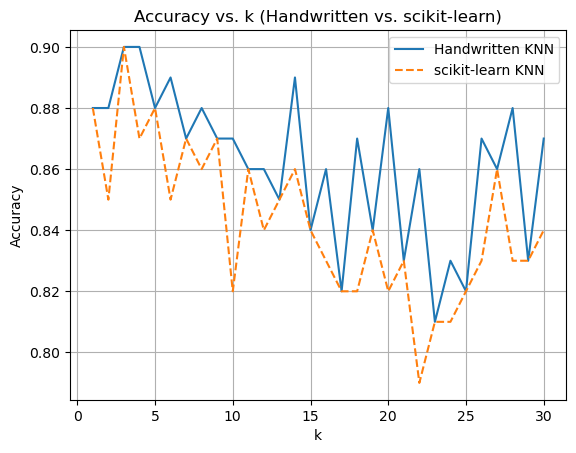

In [30]:
k_values = range(1, 31)
acc_custom = []
acc_sklearn = []

for k in k_values:
    y_pred_c = knn_predict(X_train, y_train, X_test, k)
    y_pred_s = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train).predict(X_test)
    
    acc_custom.append(np.mean(y_pred_c == y_test))
    acc_sklearn.append(np.mean(y_pred_s == y_test))

# Plot
plt.plot(k_values, acc_custom, label='Handwritten KNN')
plt.plot(k_values, acc_sklearn, label='scikit-learn KNN', linestyle='--')
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. k (Handwritten vs. scikit-learn)")
plt.legend()
plt.grid(True)
plt.show()


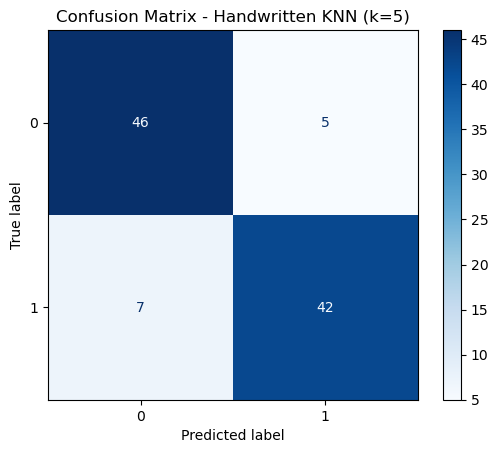

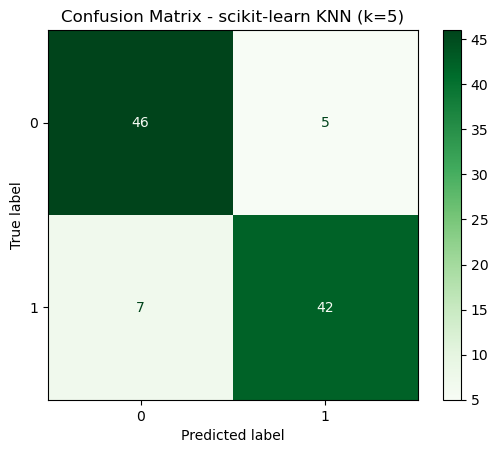

 Classification Report - Handwritten KNN (k=5)
              precision    recall  f1-score   support

     Class 0       0.87      0.90      0.88        51
     Class 1       0.89      0.86      0.88        49

    accuracy                           0.88       100
   macro avg       0.88      0.88      0.88       100
weighted avg       0.88      0.88      0.88       100

 Classification Report - scikit-learn KNN (k=5)
              precision    recall  f1-score   support

     Class 0       0.87      0.90      0.88        51
     Class 1       0.89      0.86      0.88        49

    accuracy                           0.88       100
   macro avg       0.88      0.88      0.88       100
weighted avg       0.88      0.88      0.88       100



In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


# 1. Confusion Matrix – Handwritten KNN
cm_custom = confusion_matrix(y_test, y_pred)
disp_custom = ConfusionMatrixDisplay(confusion_matrix=cm_custom)
disp_custom.plot(cmap='Blues')
plt.title("Confusion Matrix - Handwritten KNN (k=5)")
plt.show()

# 2. Confusion Matrix – scikit-learn KNN
cm_sklearn = confusion_matrix(y_test, y_pred_sklearn)
disp_sklearn = ConfusionMatrixDisplay(confusion_matrix=cm_sklearn)
disp_sklearn.plot(cmap='Greens')
plt.title("Confusion Matrix - scikit-learn KNN (k=5)")
plt.show()

# 3. Classification Report – Handwritten KNN
print(" Classification Report - Handwritten KNN (k=5)")
print(classification_report(y_test, y_pred, target_names=["Class 0", "Class 1"]))

# 4. Classification Report – scikit-learn KNN
print(" Classification Report - scikit-learn KNN (k=5)")
print(classification_report(y_test, y_pred_sklearn, target_names=["Class 0", "Class 1"]))


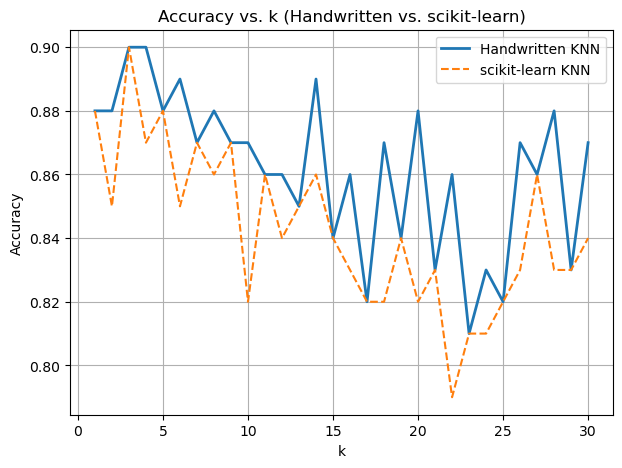

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

k_values = range(1, 31)
acc_custom = []
acc_sklearn = []

# Prepare data
X_train = dat[['x1', 'x2']].values
y_train = dat['y'].astype(int).values
X_test = test_dat[['x1', 'x2']].values
y_test = test_dat['y'].astype(int).values

# Evaluate both models over k=1 to 30
for k in k_values:
    # Handwritten KNN
    y_pred_custom = knn_predict(X_train, y_train, X_test, k)
    acc_custom.append(np.mean(y_pred_custom == y_test))
    
    # scikit-learn KNN
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train, y_train)
    y_pred_sklearn = knn_model.predict(X_test)
    acc_sklearn.append(np.mean(y_pred_sklearn == y_test))

# Plot results
plt.figure(figsize=(7, 5))
plt.plot(k_values, acc_custom, label='Handwritten KNN', linewidth=2)
plt.plot(k_values, acc_sklearn, label='scikit-learn KNN', linestyle='--')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. k (Handwritten vs. scikit-learn)')
plt.legend()
plt.grid(True)
plt.show()


In [34]:
# From your previously computed accuracy list (acc_custom or acc_sklearn)
best_k_custom = k_values[np.argmax(acc_custom)]
best_k_sklearn = k_values[np.argmax(acc_sklearn)]

print(f"Best k (Handwritten): {best_k_custom}")
print(f"Best k (scikit-learn): {best_k_sklearn}")

Best k (Handwritten): 3
Best k (scikit-learn): 3
